In [27]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img_path = "images/thermal_image_2.png"
img = cv2.imread(img_path)
if img is None:
    print("Image not found in the provided path")

image shape:  (895, 1192)
Sobel x shape:  (895, 1192)
Sobel y shape:  (895, 1192)


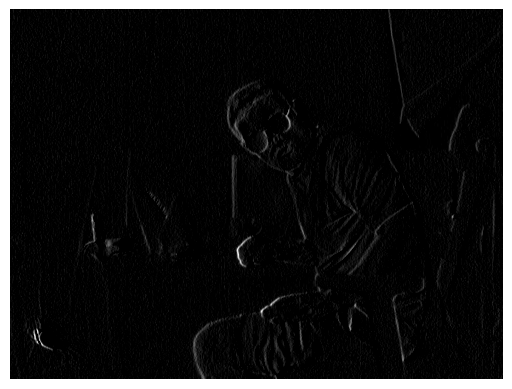

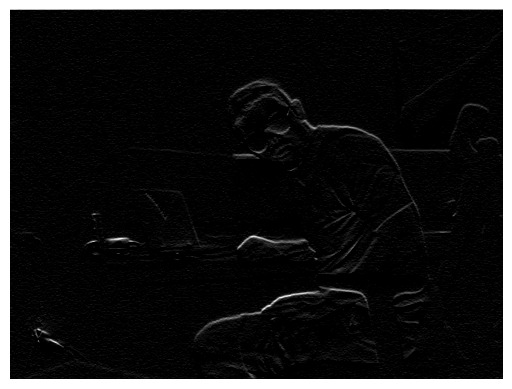

Max value in sobel x:  317.0
Max value in sobel y:  502.0


In [28]:
# sobel
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sobel_x = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=3)

print("image shape: ", gray_image.shape)
print("Sobel x shape: ", sobel_x.shape)
print("Sobel y shape: ", sobel_y.shape)

# plot sobel x
plt.imshow(sobel_x, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

# plot sobel y
plt.imshow(sobel_y, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

print("Max value in sobel x: ", sobel_x.max())
print("Max value in sobel y: ", sobel_y.max())

In [29]:
sobel_x_abs = cv2.convertScaleAbs(sobel_x)
sobel_y_abs = cv2.convertScaleAbs(sobel_y)
print("Max value in sobel x: ", sobel_x_abs.max())
print("Max value in sobel y: ", sobel_y_abs.max())

# saving
save_path = "outputs/edges/"
cv2.imwrite(save_path + "sobel_x.png", sobel_x_abs)
cv2.imwrite(save_path + "sobel_y.png", sobel_y_abs)

Max value in sobel x:  255
Max value in sobel y:  255


True

In [30]:
# joining results
sobel = cv2.addWeighted(sobel_x_abs, 0.5, sobel_y_abs, 0.5, 0) # 0 at the end is a gamma offset that acts as a brigthness parameter
cv2.imwrite(save_path + "sobel.png", sobel)

True

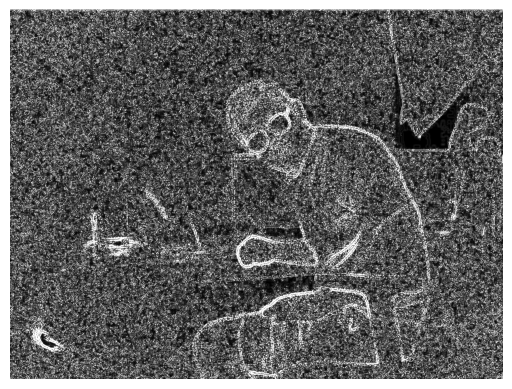

True

In [31]:
# Laplacian
# The kernel size must be odd and not larger than 31
laplacian_3 = cv2.Laplacian(gray_image, cv2.CV_64F, ksize=3)
laplacian_5 = cv2.Laplacian(gray_image, cv2.CV_64F, ksize=5)
laplacian_abs_3 = cv2.convertScaleAbs(laplacian_3)
laplacian_abs_5 = cv2.convertScaleAbs(laplacian_5)

# plot laplacian
plt.imshow(laplacian_abs_3, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

cv2.imwrite(save_path + "laplacian_3.png", laplacian_abs_3)
cv2.imwrite(save_path + "laplacian_5.png", laplacian_abs_5)

In [32]:
# laplacian with gaussian blur
blur = cv2.GaussianBlur(gray_image, (15,15), 0)
laplacian = cv2.Laplacian(blur, cv2.CV_64F, ksize=5)
laplacian_abs = cv2.convertScaleAbs(laplacian)
cv2.imwrite(save_path + "laplacian_after_blur.png", laplacian_abs)

True

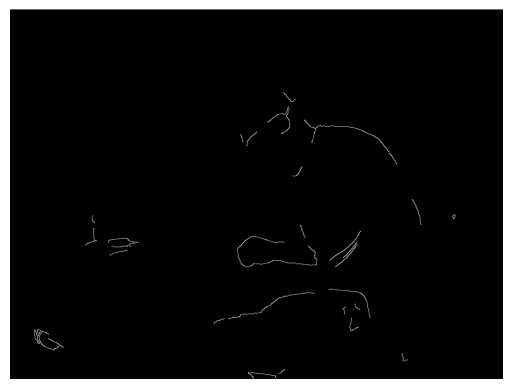

In [33]:
# Canny
# lower threshold too low  → too many weak/noisy edges
# upper threshold too high → only very strong edges remain
edges = cv2.Canny(gray_image, 100, 200)
cv2.imwrite(save_path + "canny_100_200.png", edges)
plt.imshow(edges, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()


255
0


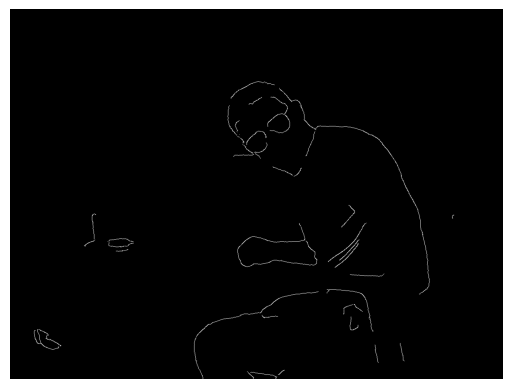

In [34]:
# gaussian blur + canny
blur_canny = cv2.Canny(blur, 10, 80)
print(blur_canny.max())
print(blur_canny.min())
cv2.imwrite(save_path + "blur_canny_10_80.png", blur_canny)
plt.imshow(blur_canny, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

In [15]:
import ipywidgets as widgets
from IPython.display import display

def apply_canny(low, high):
    edges = cv2.Canny(gray_image, low, high)
    plt.figure(figsize=(10, 5))
    plt.imshow(edges, cmap="gray", vmin=0, vmax=255)
    plt.axis("off")
    plt.show()

widgets.interact(
    apply_canny,
    low=widgets.IntSlider(min=0, max=500, step=1, value=50),
    high=widgets.IntSlider(min=0, max=500, step=1, value=150)
)

interactive(children=(IntSlider(value=50, description='low', max=500), IntSlider(value=150, description='high'…

<function __main__.apply_canny(low, high)>

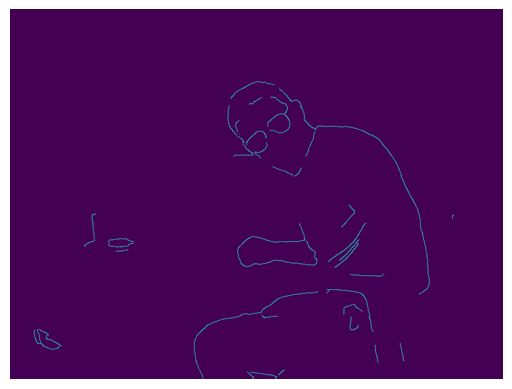

True

In [36]:
# overlay borders

gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray_image, (15, 15), 0)
edges = cv2.Canny(blur, 10, 80)
img_contour = img.copy()
img_contour[edges > 0] = [0, 0, 255]
plt.imshow(edges, vmin=0, vmax=255)
plt.axis("off")
plt.show()
cv2.imwrite(save_path + "original_with_contour.png", img_contour)